# Infrastructure Defect Data Pipeline

Converts polygon JSON annotations into a YOLOv8 segmentation dataset.

It also checks each image for quality (brightness, blur, contrast). Images that fail the check are left out of the training set, but they are still written to a CSV report so you can see what was skipped and why.


## 0 - Install dependencies


In [ ]:
! pip install ultralytics==8.2.0 opencv-python==4.9.0.80 numpy==1.26.4 tqdm==4.66.4 pyyaml==6.0.1 scikit-learn==1.5.1


## 1 - Imports


In [1]:
import os
import json
import cv2
import glob
import shutil
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split


## 2 - Configuration

All the paths and quality limits are kept here, so you can change them in one place without touching the rest of the code.


In [2]:
# Paths
RAW_IMAGES = "raw/images"            # source images (.jpg)
RAW_LABELS = "raw/labels"            # source annotations (.json, LabelMe style)
BASE = "dataset_yolo"                # output dataset folder
QUALITY_CSV = "quality_report.csv"   # quality log

# Quality limits
BRIGHTNESS_MIN = 40    # below this = too dark
BRIGHTNESS_MAX = 220   # above this = too bright
BLUR_MIN = 80          # below this = too blurry
CONTRAST_MIN = 15      # below this = too flat

# If True, skip bad images in the training set.
# If False, keep every image and only log the warnings.
EXCLUDE_FLAGGED = True


## 3 - Image quality check

`analyze_quality` looks at one image and measures three things:

- brightness: the average pixel value. Very dark or very bright images hide defects.
- blur: how sharp the image is. Blurry images miss thin cracks.
- contrast: how much the pixels vary. Flat images are hard to segment.

It returns those numbers, a `passed` flag, and a list of reasons if the image looks bad.


In [3]:
def analyze_quality(img):
    # Look at one image and return its quality numbers and any warnings.
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness = float(hsv[:, :, 2].mean())
    blur_score = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    contrast = float(gray.std())

    warnings = []
    if brightness < BRIGHTNESS_MIN:
        warnings.append("too dark")
    elif brightness > BRIGHTNESS_MAX:
        warnings.append("too bright")
    if blur_score < BLUR_MIN:
        warnings.append("too blurry")
    if contrast < CONTRAST_MIN:
        warnings.append("low contrast")

    result = {
        "brightness": round(brightness, 1),
        "blur_score": round(blur_score, 1),
        "contrast": round(contrast, 1),
        "passed": len(warnings) == 0,
        "warnings": warnings,
    }
    return result


## 4 - Load image list


In [4]:
image_files = sorted(glob.glob(f"{RAW_IMAGES}/*.jpg"))
print("Total images:", len(image_files))


Total images: 1841


## 5 - Find all class names

Read every label file and collect the names used, so we do not have to list the classes by hand.


In [5]:
all_labels = set()

for path in glob.glob(f"{RAW_LABELS}/*.json"):
    with open(path) as f:
        data = json.load(f)
    for shape in data["shapes"]:
        label = shape["label"].strip().lower()
        all_labels.add(label)

sorted_labels = sorted(all_labels)
print("Classes:", sorted_labels)


Classes: ['concrete crushing', 'delamination', 'microcrack', 'minor spalling', 'moderate spalling', 'rebar corrosion', 'structural crack', 'structural deformation']


## 6 - Give each class a number


In [6]:
class_map = {}
for idx, label in enumerate(sorted_labels):
    class_map[label] = idx

print(class_map)


{'concrete crushing': 0, 'delamination': 1, 'microcrack': 2, 'minor spalling': 3, 'moderate spalling': 4, 'rebar corrosion': 5, 'structural crack': 6, 'structural deformation': 7}


## 7 - Helper functions

`read_json` returns the shapes and the image size. `poly_to_yolo` turns polygon points into the 0-to-1 range that YOLO segmentation expects.


In [7]:
def read_json(path):
    with open(path) as f:
        data = json.load(f)
    return data["shapes"], data["imageWidth"], data["imageHeight"]


def poly_to_yolo(points, w, h):
    coords = []
    for x, y in points:
        coords.append(x / w)
        coords.append(y / h)
    return coords


## 8 - Check every image and decide what to keep

Each image is checked once and its result is written to the log. An image goes into the dataset only if it has a label and (when `EXCLUDE_FLAGGED` is True) passes the quality check. Nothing is dropped silently - every image shows up in `quality_report.csv`.


In [8]:
records = []        # images that go into the dataset
quality_log = []    # every image and its result

missing_label = 0
empty_label = 0
unreadable = 0

for img_path in tqdm(image_files):
    base = os.path.basename(img_path)
    img = cv2.imread(img_path)

    if img is None:
        unreadable += 1
        quality_log.append({"image": base, "status": "unreadable"})
        continue

    q = analyze_quality(img)

    json_path = f"{RAW_LABELS}/{base.replace('.jpg', '.json')}"
    has_label = os.path.exists(json_path)

    # Find the most common label in this image (used later for the split).
    dominant = None
    if has_label:
        shapes, _, _ = read_json(json_path)

        labels = []
        for shape in shapes:
            labels.append(shape["label"].strip().lower())

        # Count each label, then pick the one with the highest count.
        counts = {}
        for label in labels:
            counts[label] = counts.get(label, 0) + 1

        best_label = None
        best_count = -1
        for label, count in counts.items():
            if count > best_count:
                best_label = label
                best_count = count
        dominant = best_label

    # Save this image's result to the log.
    quality_log.append({
        "image": base,
        "status": "ok" if q["passed"] else "flagged",
        "brightness": q["brightness"],
        "blur_score": q["blur_score"],
        "contrast": q["contrast"],
        "warnings": "; ".join(q["warnings"]),
        "has_label": has_label,
        "class": dominant,
    })

    # Decide if this image goes into the dataset.
    if not has_label:
        missing_label += 1
        continue
    if dominant is None:
        empty_label += 1
        continue
    if EXCLUDE_FLAGGED and not q["passed"]:
        continue  # kept out of training, but still in the CSV above

    records.append({"image": img_path, "class": dominant})

# Save the quality report.
quality_df = pd.DataFrame(quality_log)
quality_df.to_csv(QUALITY_CSV, index=False)

flagged = list(quality_df["status"]).count("flagged")

print("Scanned         :", len(image_files))
print("Unreadable      :", unreadable)
print("Missing label   :", missing_label)
print("Empty label     :", empty_label)
print("Quality-flagged :", flagged, "(excluded =", str(EXCLUDE_FLAGGED) + ")")
print("Kept for dataset:", len(records))
print("Full report ->", QUALITY_CSV)


100%|██████████| 1841/1841 [00:24<00:00, 75.85it/s] 

Scanned         : 1841
Unreadable      : 0
Missing label   : 0
Empty label     : 0
Quality-flagged : 638 (excluded = True)
Kept for dataset: 1203
Full report -> quality_report.csv


## 9 - Quality report summary

A quick look at why images were flagged and the range of each metric.


In [9]:
# Count how often each warning appears.
flagged_df = quality_df[quality_df["status"] == "flagged"]

if len(flagged_df) > 0:
    reason_counts = {}
    for warning_text in flagged_df["warnings"]:
        for reason in str(warning_text).split("; "):
            reason = reason.strip()
            if reason:
                reason_counts[reason] = reason_counts.get(reason, 0) + 1

    print("Flag reasons:")
    for reason, count in reason_counts.items():
        print("  ", reason, count)
else:
    print("No images were flagged.")

# Show the range of each metric for the readable images.
readable_df = quality_df[quality_df["status"].isin(["ok", "flagged"])]

if len(readable_df) > 0:
    print()
    print("Metric ranges (min / mean / max):")
    for col in ["brightness", "blur_score", "contrast"]:
        values = pd.to_numeric(readable_df[col], errors="coerce").dropna()
        if len(values) > 0:
            print("  ", col,
                  round(values.min(), 1), "/",
                  round(values.mean(), 1), "/",
                  round(values.max(), 1))

flagged_df.head(10)


Flag reasons:
   too blurry 549
   low contrast 238
   too bright 6

Metric ranges (min / mean / max):
   brightness 70.9 / 154.4 / 232.2
   blur_score 5.5 / 390.0 / 14854.3
   contrast 6.1 / 33.5 / 77.4


,image,status,brightness,blur_score,contrast,warnings,has_label,class
61,crack1.jpg,flagged,133.8,67.5,16.0,too blurry,True,structural crack
62,crack10.jpg,flagged,152.6,61.9,13.7,too blurry; low contrast,True,structural crack
63,crack11.jpg,flagged,149.5,68.8,18.9,too blurry,True,structural crack
64,crack12.jpg,flagged,138.4,64.9,17.5,too blurry,True,structural crack
65,crack12605.jpg,flagged,185.5,52.9,21.3,too blurry,True,structural crack
66,crack12642.jpg,flagged,188.4,69.9,28.5,too blurry,True,structural crack
88,crack13.jpg,flagged,155.8,37.8,13.4,too blurry; low contrast,True,structural crack
89,crack1301.jpg,flagged,172.1,23.0,18.3,too blurry,True,structural crack
90,crack1302.jpg,flagged,165.5,22.1,14.2,too blurry; low contrast,True,microcrack
100,crack1337.jpg,flagged,209.6,62.9,29.9,too blurry,True,structural crack


## 10 - Split into train / val / test (70 / 15 / 15)


In [10]:
df = pd.DataFrame(records)

train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["class"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["class"], random_state=42
)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))


Train: 842  Val: 180  Test: 181


## 10b — Data distribution after split


── Image counts per class and split ──
class  concrete crushing  delamination  microcrack  minor spalling  moderate spalling  rebar corrosion  structural crack  structural deformation
train                 27            96          47              24                 42              294               277                      35
val                    6            20          10               5                  9               63                59                       8
test                   6            21          10               5                  9               63                60                       7


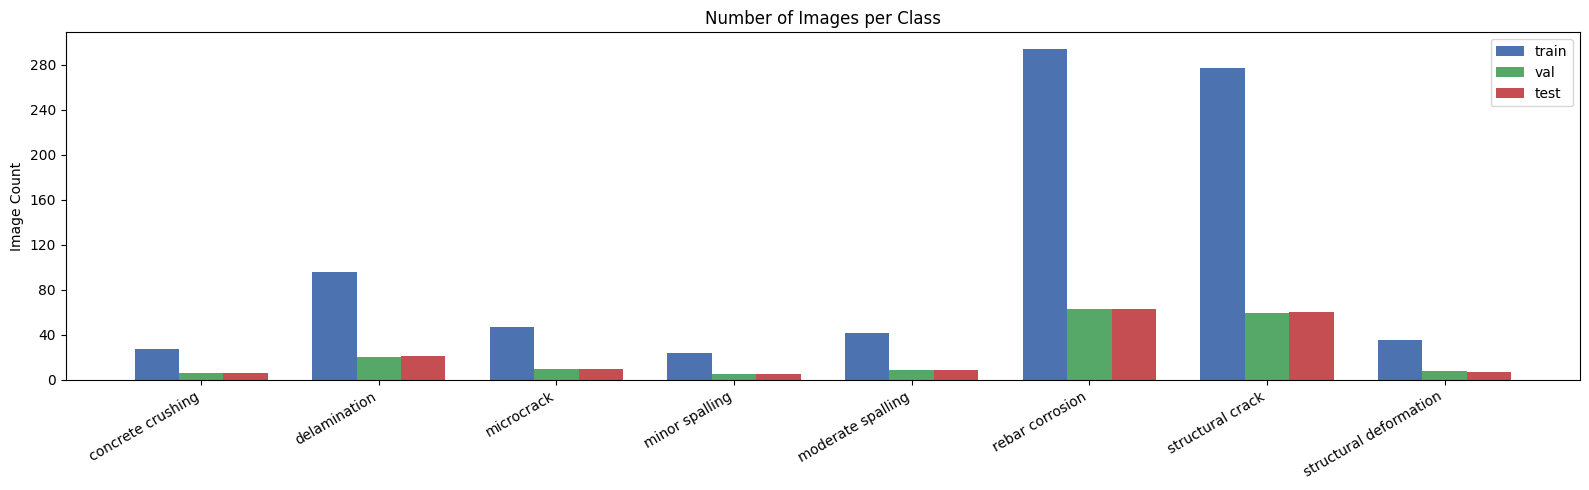

Saved: class_counts.png


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Build count table
split_frames = {
    "train": train_df,
    "val": val_df,
    "test": test_df
}

all_classes = sorted(df["class"].unique())

counts = {}
for split, frame in split_frames.items():
    counts[split] = frame["class"].value_counts().reindex(all_classes, fill_value=0)

count_df = pd.DataFrame(counts).T

print("── Image counts per class and split ──")
print(count_df.to_string())

# Bar chart
x = np.arange(len(all_classes))
width = 0.25
colors = {"train": "#4C72B0", "val": "#55A868", "test": "#C44E52"}

plt.figure(figsize=(max(10, len(all_classes) * 2), 5))

for i, (split, color) in enumerate(colors.items()):
    plt.bar(
        x + i * width,
        count_df.loc[split, all_classes],
        width,
        label=split,
        color=color
    )

plt.xticks(x + width, all_classes, rotation=30, ha="right")
plt.ylabel("Image Count")
plt.title("Number of Images per Class")
plt.legend()
plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("class_counts.png", dpi=120, bbox_inches="tight")
plt.show()

print("Saved: class_counts.png")

## 11 - Make the output folders


In [13]:
for split in ["train", "val", "test"]:
    os.makedirs(f"{BASE}/images/{split}", exist_ok=True)
    os.makedirs(f"{BASE}/labels/{split}", exist_ok=True)


## 12 - Convert to YOLO format

Write one `.txt` file per image (class id plus the polygon points) and copy the image into its split folder. The quality check is not repeated here, because `records` already holds only the images we decided to keep in step 8.


In [14]:
def process(split_df, split):
    written = 0
    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        img_path = row["image"]
        base = os.path.basename(img_path)

        json_path = f"{RAW_LABELS}/{base.replace('.jpg', '.json')}"
        shapes, w, h = read_json(json_path)

        yolo_lines = []
        for shape in shapes:
            label = shape["label"].strip().lower()
            if label not in class_map:
                continue
            cls = class_map[label]
            poly = poly_to_yolo(shape["points"], w, h)

            # Turn the numbers into one line of text: "cls x1 y1 x2 y2 ..."
            point_strings = []
            for value in poly:
                point_strings.append(str(value))
            line = str(cls) + " " + " ".join(point_strings)
            yolo_lines.append(line)

        if not yolo_lines:
            continue

        label_path = f"{BASE}/labels/{split}/{base.replace('.jpg', '.txt')}"
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_lines))

        shutil.copy(img_path, f"{BASE}/images/{split}/{base}")
        written += 1
    return written


## 13 - Run the conversion


In [15]:
for split_df, name in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
    n = process(split_df, name)
    print(name + ": wrote", n, "samples")


100%|██████████| 842/842 [00:01<00:00, 484.36it/s]


train: wrote 842 samples


100%|██████████| 180/180 [00:00<00:00, 452.17it/s]


val: wrote 180 samples


100%|██████████| 181/181 [00:00<00:00, 459.85it/s]

test: wrote 181 samples


## 14 - Write data.yaml


In [16]:
yaml_text = "path: dataset_yolo\n\n"
yaml_text += "train: images/train\n"
yaml_text += "val: images/val\n"
yaml_text += "test: images/test\n\n"
yaml_text += "names:\n"
for label, idx in class_map.items():
    yaml_text += "  " + str(idx) + ": " + label + "\n"

with open("dataset_yolo/data.yaml", "w") as f:
    f.write(yaml_text)

print(yaml_text)
print("data.yaml created")


path: dataset_yolo

train: images/train
val: images/val
test: images/test

names:
  0: concrete crushing
  1: delamination
  2: microcrack
  3: minor spalling
  4: moderate spalling
  5: rebar corrosion
  6: structural crack
  7: structural deformation

data.yaml created


## 15 - Check the result by plotting 5 images

Draw the polygons and labels on a few converted images to make sure everything came through correctly.


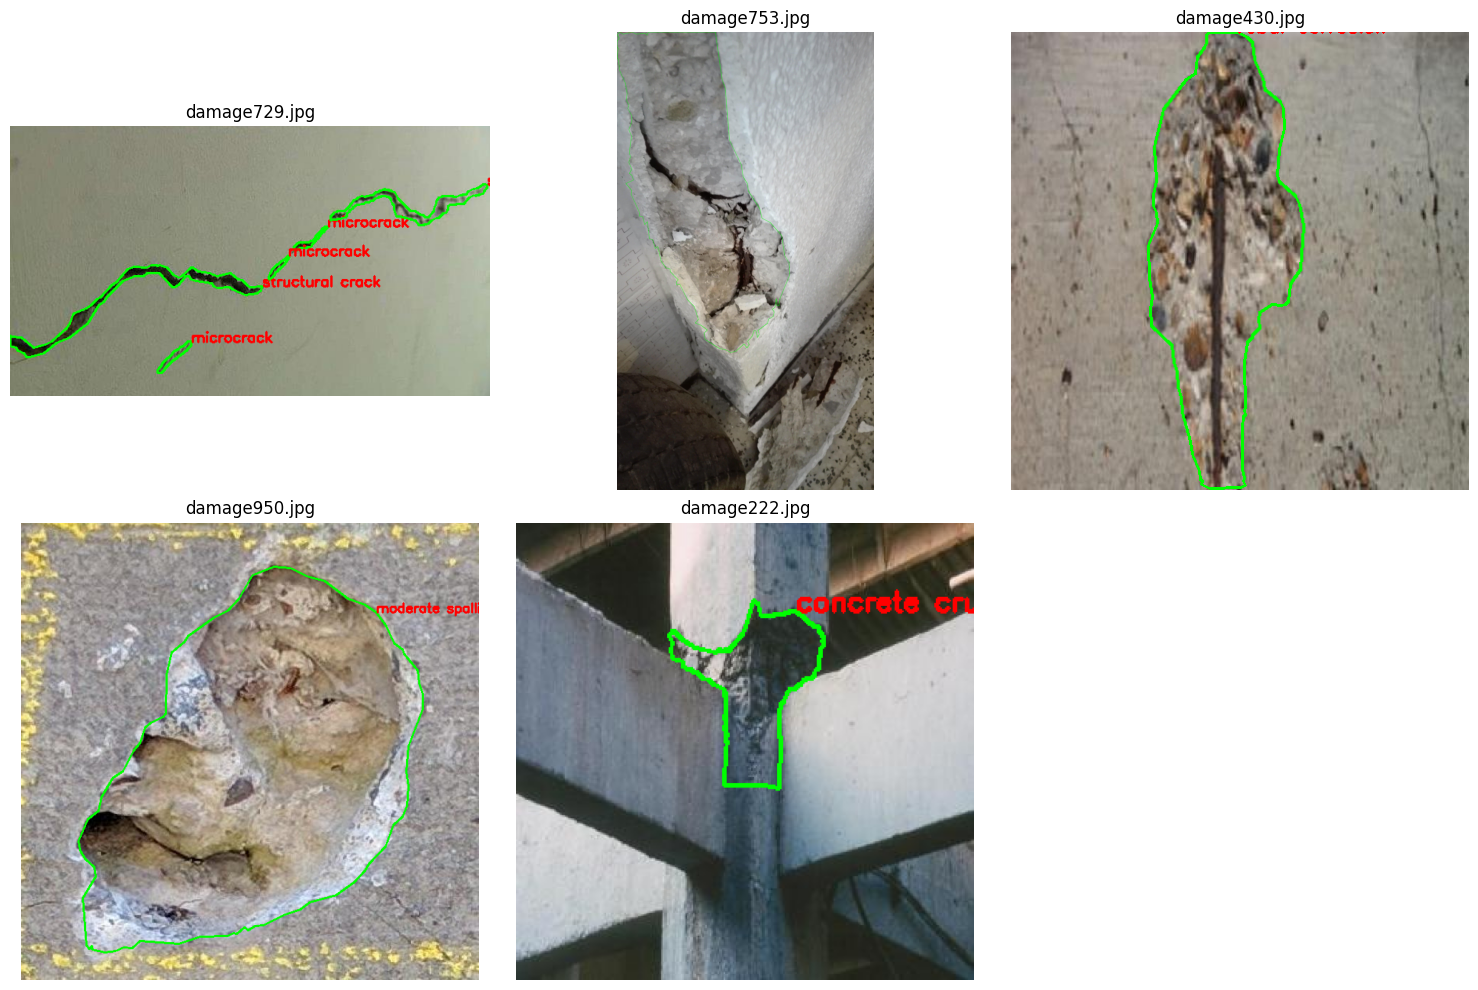

In [17]:
import matplotlib.pyplot as plt
import random

# Reverse the class map so we can go from id back to name.
idx_to_class = {}
for label, idx in class_map.items():
    idx_to_class[idx] = label

image_paths = glob.glob(f"{BASE}/images/train/*.jpg")
samples = random.sample(image_paths, min(5, len(image_paths)))


def draw_yolo_polygon(img, label_path):
    h, w, _ = img.shape
    if not os.path.exists(label_path):
        return img

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        cls = int(parts[0])

        coords = []
        for value in parts[1:]:
            coords.append(float(value))

        pts = []
        for i in range(0, len(coords), 2):
            x = int(coords[i] * w)
            y = int(coords[i + 1] * h)
            pts.append([x, y])

        pts = np.array(pts, np.int32).reshape((-1, 1, 2))
        cv2.polylines(img, [pts], True, (0, 255, 0), 2)

        x, y = pts[0][0]
        cv2.putText(img, idx_to_class.get(cls, str(cls)), (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    return img


plt.figure(figsize=(15, 10))
for i, img_path in enumerate(samples):
    base = os.path.basename(img_path)
    label_path = f"{BASE}/labels/train/{base.replace('.jpg', '.txt')}"
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = draw_yolo_polygon(img, label_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(base)
plt.tight_layout()
plt.show()
